In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.shape

(9568, 5)

In [5]:
# AT => Temprature
# V => Vaccum
# AP => Pressure
# RH => Humidity

# PE => Produced energy

In [6]:
df.isnull().sum()


AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [8]:
print(X, '/n')
print(y)

         AT      V       AP     RH
0      8.34  40.77  1010.84  90.01
1     23.64  58.49  1011.40  74.20
2     29.74  56.90  1007.15  41.91
3     19.07  49.69  1007.22  76.79
4     11.80  40.66  1017.13  97.20
...     ...    ...      ...    ...
9563  15.12  48.92  1011.80  72.93
9564  33.41  77.95  1010.30  59.72
9565  15.99  43.34  1014.20  78.66
9566  17.65  59.87  1018.58  94.65
9567  23.68  51.30  1011.86  71.24

[9568 rows x 4 columns] /n
0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64


In [9]:
# Split data

from sklearn.model_selection import train_test_split

X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(x_test)

In [11]:
X_test_scaled

array([[ 0.46957986,  1.48702903, -0.73951683,  1.18192703],
       [ 0.9959235 ,  0.64895632, -0.36314369, -0.16446843],
       [-0.90277162, -1.08120705,  0.54082395,  1.46975828],
       ...,
       [ 1.08135101,  1.11208086, -0.86217415, -1.14527729],
       [ 1.67796566,  1.14385613, -1.27887298, -1.66160017],
       [-0.84903496, -0.90644307,  0.12580535,  1.18806561]],
      shape=(1914, 4))

## Data converted to Tensor

In [12]:
import torch
import torch.nn as nn

# if we have numpy data array then data -> tensor like this
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

#if we have pandas dataframe then data -> tensor like this
y_train_tensor= torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [13]:
type(y_train)

pandas.core.series.Series

In [14]:
y_train.shape

(7654,)

In [15]:
y_train_tensor.shape

torch.Size([7654, 1])

In [17]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [27]:
# Defining ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
            
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),  
            
            # Output Layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [44]:
import torch.optim as optim


model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [45]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        

epoch 1/100 ==> train loss = 205163.241015625 & val loss = 201418.234375
epoch 2/100 ==> train loss = 188158.6033203125 & val loss = 168404.140625
epoch 3/100 ==> train loss = 137575.50068359374 & val loss = 104137.5859375
epoch 4/100 ==> train loss = 72485.09272460938 & val loss = 47621.85546875
epoch 5/100 ==> train loss = 33694.715584309895 & val loss = 26298.17578125
epoch 6/100 ==> train loss = 22110.245479329427 & val loss = 20318.0234375
epoch 7/100 ==> train loss = 17759.308170572916 & val loss = 16458.5234375
epoch 8/100 ==> train loss = 14221.551440429688 & val loss = 12982.052734375
epoch 9/100 ==> train loss = 11077.235430908204 & val loss = 9904.931640625
epoch 10/100 ==> train loss = 8288.708024088543 & val loss = 7245.47412109375
epoch 11/100 ==> train loss = 5937.919222005208 & val loss = 5042.43701171875
epoch 12/100 ==> train loss = 4038.3503448486326 & val loss = 3325.8935546875
epoch 13/100 ==> train loss = 2573.697198486328 & val loss = 2099.17724609375
epoch 14/10

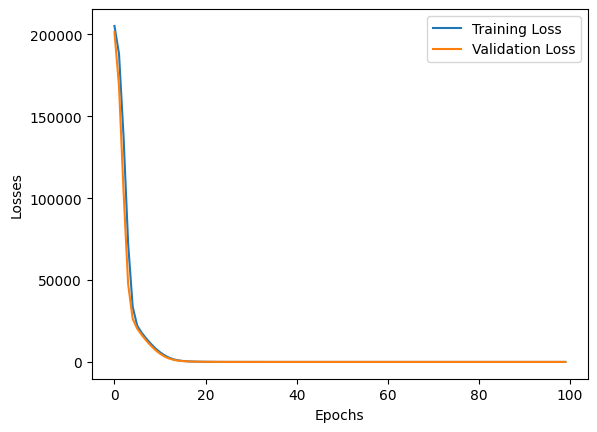

In [46]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()